Ce notebook contient des comptes et des visualisations des annotations. L'analyse de ces annotations doit bien se faire en fonction des guidelines. Chaque question est scorée d'une manière différente, donc, pour chaque question, les scores ont une interprétation différente. Cette analyse nous servira pour comparer mes résultats/conclusions avec ceux/celles des métriques automatiques.

#Imports et configuration

In [ ]:
# Uniquement pour Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Uniquement pour Colab
%cd '/content/drive/MyDrive/FAC/Master/M2/Stage/Code/Qualitative_evaluation'
# path Maïwenn à changer

/content/drive/MyDrive/FAC/Master/M2/Stage/Code/Qualitative_evaluation


In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Analyse, par question, des supplétifs

##Ajout du label

In [ ]:
# Création d'un fichier par question, contenant les réponses ET les scores des entrées du fichier Shuffled
# Nécessité d'ajouter la colonne label du jeu de données de référence pour ne pouvoir traiter que les entrées supplétives
gold_dataset = pd.read_csv("./gold_dataset.csv")
gold_dataset = gold_dataset.sort_values(by=["lemma"], ascending=True).reset_index().drop(columns=["index"])

questions = ["proc", "aff", "rad", "etym_mean", "lang", "base", "etym_fam"]

dfs = {}

for q in questions:
    annot_file = pd.read_csv(f"./{q}_annotation.csv")
    s_annot_file = annot_file[annot_file["source"] == "S"].reset_index().drop(columns=["index"])
    s_annot_file["label"] = [ "" for i in range(len(s_annot_file)) ]

    for idx, row in gold_dataset.iterrows():
        s_annot_file.loc[idx, "label"] = row["label"]

    dfs[q] = s_annot_file

# Les fichiers par question :
s_proc = dfs["proc"]
s_aff = dfs["aff"]
s_rad = dfs["rad"]
s_etym_mean = dfs["etym_mean"]
s_lang = dfs["lang"]
s_base = dfs["base"]
s_etym_fam = dfs["etym_fam"]

##Q1 - proc

In [ ]:
s_proc

,source,lemma,proc,score,label
0,S,actinique,['Composé'],0.0,supplétion régulière
1,S,adipeux,['Suffixation'],1.0,supplétion régulière
2,S,an,[],1.0,non dérivé
3,S,antifébrile,['Composé'],0.5,supplétion régulière
4,S,arbre,[],1.0,non dérivé
...,...,...,...,...,...
95,S,verbe,[],1.0,non dérivé
96,S,viaire,['Suffixation'],1.0,supplétion rare
97,S,visible,[],0.5,supplétion régulière
98,S,école,[],1.0,non dérivé


In [ ]:
# Nombre de réponses correctes dérivés et non dérivés confondus
proc_words = []
suppletion = 0
non_derive = 0

for idx, row in s_proc.iterrows() :
  if row["score"] == 1 :
    proc_words.append(row["lemma"])
    if row["label"] == "non dérivé" :
      non_derive += 1
    else :
      suppletion += 1

print(f"Le nombre d'entrées qui ont eu une réponse correcte (score=1) : {len(proc_words)}/100")
print(f"Le nombre de supplétions : {suppletion}/50")
print(f"Le nombre de non dérivés : {non_derive}/50")

Le nombre d'entrées qui ont eu une réponse correcte (score=1) : 57/100
Le nombre de supplétions : 10/50
Le nombre de non dérivés : 47/50


La question du procédé morphologique sera la seule question avec une analyse sur les non dérivés. Pourquoi ? Parce que c'est la seule question où le LLM doit réfléchir sur l'ensemble des entrées, ensuite, s'il répond correctement à cette question pour les non dérivés, il n'aura pas à répondre aux prochaines. Ici on peut voir que 57 entrées ont été correctement identifiées, dont 10 supplétions et 47 non dérivés. Cela signifie que le LLM a eu juste a presque tous les non dérivés et qu'on peut facilement lui faire répondre comme on veut aux questions suivantes.

In [ ]:
# Fichier contenant les scores des entrées supplétives, pour la question du procédé morphologique
s_proc_sup = s_proc[s_proc["label"] != "non dérivé"].reset_index().drop(columns=["index"])

# Nombre de réponses correctes
proc_words = []

for idx, row in s_proc_sup.iterrows() :
  if row["score"] == 1 :
    proc_words.append(row["lemma"])

print(f"Le nombre d'entrées qui ont eu une réponse correcte (score=1) : {len(proc_words)}/50")
print(f"Les entrées en question : {proc_words}")

print("\n------------------------------------------------------------------------------------\n")

# Analyse du contexte des réponses correctes
contexts = {}

for word in proc_words :
  for idx, row in gold_dataset.iterrows() :
    if row["lemma"] == word :
      context = row["etym"]
      contexts[word] = context

print(f"Le contexte étymologique des entrées ayant eu une bonne réponse : \n")
contexts

Le nombre d'entrées qui ont eu une réponse correcte (score=1) : 10/50
Les entrées en question : ['adipeux', 'funiculaire', 'gravidisme', 'humain', 'kérosène', 'lactique', 'ovoïde', 'polyadelphe', 'potable', 'viaire']

------------------------------------------------------------------------------------

Le contexte étymologique des entrées ayant eu une bonne réponse : 



{'adipeux': "['Dérivé savant du latin adeps, adipis (« graisse ») avec le suffixe -eux.']",
 'funiculaire': "['(Nom commun 1)Dérivé de funicule, avec le suffixe -aire.']",
 'gravidisme': "['Dérivé de gravide, avec le suffixe -isme.']",
 'humain': "['Du latin humanus,dérivé de homo (« homme »), avec le suffixe -anus.Dérivé de humus (« terre »), avec le suffixe -o, -onis, -inis, littéralement « terrien »']",
 'kérosène': "['Appelé d’abord kérosine en 1862, puis kérosène à partir de 1865 ; emprunté à l’anglais kerosene, lui-même dérivé du grec κηρός kêros, « cire » avec le suffixe anglais -ene (français -ène).']",
 'lactique': "['Du latin lac, lactis (« lait ») avec le suffixe -ique.']",
 'ovoïde': "['Motdérivé de ove, avec le suffixe -oïde.']",
 'polyadelphe': "['Motdérivé de adelphe (« frère »), avec le préfixe poly- (« plusieurs »).']",
 'potable': "['Du latin potabilis (« qui peut être bu, potable »), dérivé de potare (« boire »).']",
 'viaire': "['et (nom commun 1) Du latin via, avec

Nous remarquons que la mention du procédé morphologique était assez explicite : "avec le suffixe -...". Seule une entrée fait exception : potable.

In [ ]:
# Nombre d'entrées pour lesquelles le LLM n'avait pas accès à la réponse
words = []

for idx, row in s_proc_sup.iterrows() :
  if row["score"] == 0.5 :
    words.append(row["lemma"])

print(f"Le nombre d'entrées pour lesquelles aucune information n'était donnée dans le contexte (score=0.5) : {len(words)}/50")
print(f"Les entrées en question : {words}")

Le nombre d'entrées pour lesquelles aucune information n'était donnée dans le contexte (score=0.5) : 30/50
Les entrées en question : ['antifébrile', 'bibition', 'caprin', 'cardiaque', 'carnassier', 'caséeux', 'chthonien', 'comestible', 'coturnisme', 'céleste', 'gibbeux', 'gigantesque', 'igné', 'lectrice', 'ligneux', 'malachite', 'marmoréen', 'myrmicéen', 'nucléé', 'nutrition', 'oblation', 'patibulaire', 'pétré', 'rupestre', 'scolaire', 'strabisme', 'studieux', 'thalassique', 'visible', 'évier']


Nous constatons que pour plus de la moitié des entrées (30/50), le LLM n'avait pas accès au procédé morphologique. Un score bas (10 bonnes réponses sur 50) était donc attendu.

##Q2 - aff

In [ ]:
# Fichier contenant les scores des entrées supplétives, pour la question de l'affixe
s_aff_sup = s_aff[s_aff["label"] != "non dérivé"].reset_index().drop(columns=["index"])

# Nombre de réponses correctes
aff_words = []

for idx, row in s_aff_sup.iterrows() :
  if row["score"] == 1 :
    aff_words.append(row["lemma"])

print(f"Le nombre d'entrées qui ont eu une réponse correcte (score=1) : {len(aff_words)}/50")
print(f"Les entrées en question : {aff_words}")

print("\n------------------------------------------------------------------------------------\n")

# Analyse du contexte des réponses correctes
contexts = {}

for word in aff_words :
  for idx, row in gold_dataset.iterrows() :
    if row["lemma"] == word :
      context = row["etym"]
      contexts[word] = context

print(f"Le contexte étymologique des entrées ayant eu une bonne réponse : \n")
contexts

Le nombre d'entrées qui ont eu une réponse correcte (score=1) : 10/50
Les entrées en question : ['actinique', 'adipeux', 'crustacé', 'céphalaire', 'divitisme', 'funiculaire', 'gravidisme', 'kérosène', 'ovoïde', 'thélite']

------------------------------------------------------------------------------------

Le contexte étymologique des entrées ayant eu une bonne réponse : 



{'actinique': "['Composé du grec ancien ἀκτίς, ἀκτῖνος, aktis, aktinos (« rayon ») et du suffixe -ique.']",
 'adipeux': "['Dérivé savant du latin adeps, adipis (« graisse ») avec le suffixe -eux.']",
 'crustacé': "['Du latin crusta (« croûte ») et -acé.']",
 'céphalaire': "['Du grec ancien κεφαλή, képhalê (« tête ») et -aire.']",
 'divitisme': "['Du latin dives (gén.: divitis), « riche », et du suffixe -isme.']",
 'funiculaire': "['(Nom commun 1)Dérivé de funicule, avec le suffixe -aire.']",
 'gravidisme': "['Dérivé de gravide, avec le suffixe -isme.']",
 'kérosène': "['Appelé d’abord kérosine en 1862, puis kérosène à partir de 1865 ; emprunté à l’anglais kerosene, lui-même dérivé du grec κηρός kêros, « cire » avec le suffixe anglais -ene (français -ène).']",
 'ovoïde': "['Motdérivé de ove, avec le suffixe -oïde.']",
 'thélite': "['Du grec ancien θηλή, thêlế (« mamelle ») et -ite.']"}

Nous remarquons que pour toutes les entrées, la mention d'un affixe était assez explicite : "avec le suffixe -..." ou "-...".

In [ ]:
# Comparaison des réponses correctes avec proc
common_words_proc_aff = []

for word in aff_words :
  for w in proc_words :
    if word == w :
      common_words_proc_aff.append(word)

print(f"Les entrées correctes qu'ont en commun proc et aff : {len(common_words_proc_aff)} {common_words_proc_aff}")

Les entrées correctes qu'ont en commun proc et aff : 5 ['adipeux', 'funiculaire', 'gravidisme', 'kérosène', 'ovoïde']


L'hypothèse était que, si le LLM trouvait l'affixe, alors il trouvait à coup sûr le procédé morphologique. L'inverse n'est pas forcément vrai, il pourrait trouver le procédé morphologique mais ne pas savoir délimiter l'affixe du radical.

Ce qui est surprenant, c'est que cette hypothèse se vérifie pour seulement 5 entrées. Le LLM a trouvé le bon affixe pour 10 entrées au total, ce qui signifie que pour 5 d'entre elles, il n'a pas sû identifier le procédé morphologique.

##Q3 - rad

In [ ]:
# Fichier contenant les scores des entrées supplétives, pour la question du radical
s_rad_sup = s_rad[s_rad["label"] != "non dérivé"].reset_index().drop(columns=["index"])

# Nombre de réponses correctes
rad_words = []

for idx, row in s_rad_sup.iterrows() :
  if row["score"] == 1 :
    rad_words.append(row["lemma"])

print(f"Le nombre d'entrées qui ont eu une réponse correcte (score=1) : {len(rad_words)}/50")
print(f"Les entrées en question : {rad_words}")

print("\n------------------------------------------------------------------------------------\n")

# Comparaison des réponses correctes avec proc et aff
common_words_rad_proc_aff = []

for word in common_words_proc_aff :
  for w in rad_words :
    if word == w :
      common_words_rad_proc_aff.append(word)

print(f"Les entrées correctes pour lesquelles le proc et l'aff ont déjà bien été identifiés : {len(common_words_rad_proc_aff)}/{len(common_words_proc_aff)} {common_words_rad_proc_aff}")

print("\n------------------------------------------------------------------------------------\n")

# Comparaison des réponses correctes avec proc
common_words_rad_proc = []

for word in proc_words :
  for w in rad_words :
    if word == w :
      common_words_rad_proc.append(word)

for word in common_words_rad_proc_aff :
  for w in common_words_rad_proc :
    if word == w :
      common_words_rad_proc.remove(word)

print(f"Les entrées correctes pour lesquelles seul le proc avait déjà bien été identifié : {len(common_words_rad_proc)}/{len(proc_words)} {common_words_rad_proc}")

print("\n------------------------------------------------------------------------------------\n")

# Comparaison des réponses correctes avec aff
common_words_rad_aff = []

for word in aff_words :
  for w in rad_words :
    if word == w :
      common_words_rad_aff.append(word)

for word in common_words_rad_proc_aff :
  for w in common_words_rad_aff :
    if word == w :
      common_words_rad_aff.remove(word)

print(f"Les entrées correctes pour lesquelles seul l'aff avait déjà bien été identifié : {len(common_words_rad_aff)}/{len(aff_words)} {common_words_rad_aff}")

common_lists = common_words_rad_proc_aff + common_words_rad_proc + common_words_rad_aff
context_list = rad_words

for word in common_lists :
  for w in context_list :
    if word == w :
      context_list.remove(word)

print("\n------------------------------------------------------------------------------------\n")

# Analyse du contexte des réponses correctes
contexts = {}

for word in context_list :
  for idx, row in gold_dataset.iterrows() :
    if row["lemma"] == word :
      context = row["etym"]
      contexts[word] = context

print(f"Le contexte étymologique des {len(contexts)} entrées qui restent : \n")
contexts

Le nombre d'entrées qui ont eu une réponse correcte (score=1) : 14/50
Les entrées en question : ['adipeux', 'carnassier', 'coturnisme', 'céphalaire', 'divitisme', 'gravidisme', 'lactique', 'lectrice', 'ligneux', 'locataire', 'nucléé', 'potable', 'rupestre', 'studieux']

------------------------------------------------------------------------------------

Les entrées correctes pour lesquelles le proc et l'aff ont déjà bien été identifiés : 2/5 ['adipeux', 'gravidisme']

------------------------------------------------------------------------------------

Les entrées correctes pour lesquelles seul le proc avait déjà bien été identifié : 2/10 ['lactique', 'potable']

------------------------------------------------------------------------------------

Les entrées correctes pour lesquelles seul l'aff avait déjà bien été identifié : 2/10 ['céphalaire', 'divitisme']

------------------------------------------------------------------------------------

Le contexte étymologique des 8 entrées q

{'carnassier': "['De l’occitan carnassièr.']",
 'coturnisme': "['Du latin coturnix « caille ».']",
 'lectrice': "['Du latin lectrix (« celle qui lit »).']",
 'ligneux': "['Du latin lignosus (« comme du bois »), de lignum (« bois »).']",
 'locataire': "['Dérivé savant du latin locatum (« louer ») et -aire.']",
 'nucléé': "['Du latin nucleatus (« à noyau »).']",
 'rupestre': "['Du latin rupes (« roche »), via le latin scientifique rupestris → voir campestris et champêtre. La première attestion selon le Petit Robert et Usito serait 1812, mais le terme est au moins de deux ans plus ancien, comme le montre la source.']",
 'studieux': "['Du latin studiosus.']"}

Suivant la même logique, l'hypothèse était que, si le LLM trouvait l'affixe, alors il trouvait forcément le radical (= le lemme - l'affixe). Une hypothèse qui semblait encore plus probable était que, si le LLM trouvait à la fois le procédé morphologique ET l'affixe, alors il trouvait forcément le radical.

Etonnamment (ou pas), l'hypothèse la plus probable s'est vérifiée pour seulement 2 entrées sur 5 (5=nombre d'entrées en commun entre proc et aff).

Pour 4 entrées, le LLM avait déjà soit trouvé le procédé morphologique (lactique/potable) soit l'affixe (céphalaire/divitisme).

Cela signifie que le LLM a réussi à identifier un radical lorsqu'il n'avait même pas réussi à identifier un affixe, ni même un procédé morphologique, et ce 8 fois.

En enquêtant sur ces 8 entrées, nous constatons qu'aucune information sur un potentiel affixe ou procédé morphologique n'était mentionnée dans le contexte pour 7 entrées sur 8 => locataire est l'exception.

##Q4 - etym mean

In [ ]:
# Fichier contenant les scores des entrées supplétives, pour la question des couples étymon/sens
s_etym_mean_sup = s_etym_mean[s_etym_mean["label"] != "non dérivé"].reset_index().drop(columns=["index"])

# Nombre de réponses correctes
etym_mean_words = []

for idx, row in s_etym_mean_sup.iterrows() :
  if row["score"] == 1 :
    etym_mean_words.append(row["lemma"])

print(f"Le nombre d'entrées qui ont eu une réponse correcte (score=1) : {len(etym_mean_words)}/50")
print(f"Les entrées en question : {etym_mean_words}")

print("\n------------------------------------------------------------------------------------\n")

# Nombre d'entrées pour lesquelles le LLM a fait une petite erreur (un couple n'allait pas ou un couple manquait...)
words = []

for idx, row in s_proc_sup.iterrows() :
  if row["score"] == 0.5 :
    words.append(row["lemma"])

print(f"Le nombre d'entrées pour lesquelles la prédiction n'était pas parfaite (score=0.5) : {len(words)}/50")
print(f"Les entrées en question : {words}")

Le nombre d'entrées qui ont eu une réponse correcte (score=1) : 5/50
Les entrées en question : ['crustacé', 'gigantesque', 'ligneux', 'rupestre', 'thélite']

------------------------------------------------------------------------------------

Le nombre d'entrées pour lesquelles la prédiction n'était pas parfaite (score=0.5) : 30/50
Les entrées en question : ['antifébrile', 'bibition', 'caprin', 'cardiaque', 'carnassier', 'caséeux', 'chthonien', 'comestible', 'coturnisme', 'céleste', 'gibbeux', 'gigantesque', 'igné', 'lectrice', 'ligneux', 'malachite', 'marmoréen', 'myrmicéen', 'nucléé', 'nutrition', 'oblation', 'patibulaire', 'pétré', 'rupestre', 'scolaire', 'strabisme', 'studieux', 'thalassique', 'visible', 'évier']


Le LLM a répondu parfaitement pour 5 entrées ! C'est-à-dire qu'il a donné TOUS les couples étymon/sens, quand il y en avait plusieurs, et il a donné le bon etymon ET le bon sens pour chaque couple étymon/sens. Pour 30 entrées, le LLM sort des choses très intéressantes.

##Q5 - lang

In [ ]:
# Fichier contenant les scores des entrées supplétives, pour la question de la langue source
s_lang_sup = s_lang[s_lang["label"] != "non dérivé"].reset_index().drop(columns=["index"])

# Nombre de réponses correctes
lang_words = []

for idx, row in s_lang_sup.iterrows() :
  if row["score"] == 1 :
    lang_words.append(row["lemma"])

print(f"Le nombre d'entrées qui ont eu une réponse correcte (score=1) : {len(lang_words)}/50")
print(f"Les entrées en question : {lang_words}")

print("\n------------------------------------------------------------------------------------\n")

# Nombre d'entrées pour lesquelles le LLM n'avait pas la bonne réponse
words = {}

for idx, row in s_lang_sup.iterrows() :
  if row["score"] == 0.5 or row["score"] == 0 :
    words[row["lemma"]] = row["score"]

print(f"Le nombre d'entrées pour lesquelles il n'a pas trouvé la bonne réponse (score=0 et score=0.5) : {len(words)}/50")
print(f"Les entrées en question : {words}")

print("\n------------------------------------------------------------------------------------\n")

# Analyse des réponses incorrectes
responses = {}

for k, v in words.items() :
  for idx, row in s_lang_sup.iterrows() :
    if row["lemma"] == k :
      response = row["lang"]
      responses[k] = response

print(f"Les réponses qui ont valu 0 ou 0.5 : {responses}")

contexts = {}

for k, v in words.items() :
  for idx, row in gold_dataset.iterrows() :
    if row["lemma"] == k :
      context = row["etym"]
      contexts[k] = context

print(f"Leur contexte étymologique :\n")
contexts

Le nombre d'entrées qui ont eu une réponse correcte (score=1) : 41/50
Les entrées en question : ['actinique', 'adipeux', 'antifébrile', 'bibition', 'caprin', 'cardiaque', 'carnassier', 'caséeux', 'comestible', 'coturnisme', 'crustacé', 'céleste', 'divitisme', 'fabisme', 'foliacé', 'gibbeux', 'humain', 'igné', 'lactique', 'lectrice', 'ligneux', 'locataire', 'malachite', 'marmoréen', 'myrmicéen', 'nucléé', 'nutrition', 'oblation', 'ovoïde', 'pancalisme', 'patibulaire', 'potable', 'pétré', 'rupestre', 'scolaire', 'sigillaire', 'strabisme', 'studieux', 'thélite', 'viaire', 'visible']

------------------------------------------------------------------------------------

Le nombre d'entrées pour lesquelles il n'a pas trouvé la bonne réponse (score=0.5 et score=0) : 9/50
Les entrées en question : {'chthonien': 0.5, 'céphalaire': 0.5, 'funiculaire': 0.0, 'gigantesque': 0.0, 'gravidisme': 0.0, 'kérosène': 0.5, 'polyadelphe': 0.5, 'thalassique': 0.0, 'évier': 0.0}

------------------------------

{'chthonien': "['Du grec ancien χθόνιος, khthónios (« souterrain »), de χθών, khthṓn (« terre »).']",
 'céphalaire': "['Du grec ancien κεφαλή, képhalê (« tête ») et -aire.']",
 'funiculaire': "['(Nom commun 1)Dérivé de funicule, avec le suffixe -aire.']",
 'gigantesque': "['De l’italien gigantesco, dérivé de gigante (« géant »).']",
 'gravidisme': "['Dérivé de gravide, avec le suffixe -isme.']",
 'kérosène': "['Appelé d’abord kérosine en 1862, puis kérosène à partir de 1865 ; emprunté à l’anglais kerosene, lui-même dérivé du grec κηρός kêros, « cire » avec le suffixe anglais -ene (français -ène).']",
 'polyadelphe': "['Motdérivé de adelphe (« frère »), avec le préfixe poly- (« plusieurs »).']",
 'thalassique': "['Du latin thalassicus (« couleur de la mer »).']",
 'évier': "['euwier. Eve est une variante du XIᵉ siècle de eau, à rapprocher avec son équivalent poitevin-saintongeais ève/aeve ou wallon aiwî. Évier désigne le récipient qui contient l’eau, comme aiguière dont il est le double

Nous remarquons que le LLM a fait peu d'erreurs à cette question (19).

4 entrées avaient répondu grec au lieu de grec ancien.

##Q6 - base

In [ ]:
# Fichier contenant les scores des entrées supplétives, pour la question de la base
s_base_sup = s_base[s_base["label"] != "non dérivé"].reset_index().drop(columns=["index"])

# Nombre de réponses correctes
base_words = []

for idx, row in s_base_sup.iterrows() :
  if row["score"] == 1 :
    base_words.append(row["lemma"])

print(f"Le nombre d'entrées qui ont eu une réponse correcte (score=1) : {len(base_words)}/50")
print(f"Les entrées en question : {base_words}")

Le nombre d'entrées qui ont eu une réponse correcte (score=1) : 12/50
Les entrées en question : ['caséeux', 'coturnisme', 'céleste', 'kérosène', 'ligneux', 'nutrition', 'polyadelphe', 'pétré', 'rupestre', 'scolaire', 'thélite', 'viaire']


##Q7 - etym fam

In [ ]:
# Fichier contenant les scores des entrées supplétives, pour la question des mots faisant partie de la même famille dérivationnelle que l'entrée mais avec le radical étymologique
s_etym_fam_sup = s_etym_fam[s_etym_fam["label"] != "non dérivé"].reset_index().drop(columns=["index"])

# Nombre de réponses correctes
etym_fam_words = []

for idx, row in s_etym_fam_sup.iterrows() :
  if row["score"] == 1 :
    etym_fam_words.append(row["lemma"])

print(f"Le nombre d'entrées qui ont eu une réponse correcte (score=1) : {len(etym_fam_words)}/50")
print(f"Les entrées en question : {etym_fam_words}")

Le nombre d'entrées qui ont eu une réponse correcte (score=1) : 2/50
Les entrées en question : ['cardiaque', 'oblation']


#Classement

##Quelle question est plus difficile ? 🥲

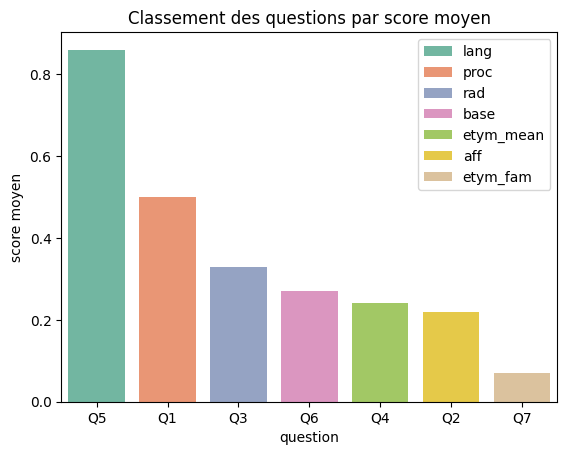

In [ ]:
# Calcul des scores moyens par question
mean_score_q1 = s_proc_sup["score"].mean()
mean_score_q2 = s_aff_sup["score"].mean()
mean_score_q3 = s_rad_sup["score"].mean()
mean_score_q4 = s_etym_mean_sup["score"].mean()
mean_score_q5 = s_lang_sup["score"].mean()
mean_score_q6 = s_base_sup["score"].mean()
mean_score_q7 = s_etym_fam_sup["score"].mean()

# Construction d'un dataframe associant les questions à leur score moyen
ar = np.array([[mean_score_q1, mean_score_q2, mean_score_q3, mean_score_q4, mean_score_q5, mean_score_q6, mean_score_q7]])
df = pd.DataFrame(ar, columns = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6','Q7'])
df = df.melt(var_name="question", value_name="score moyen").sort_values(by="score moyen", ascending=False)

# Classement des questions les mieux réussies aux moins réussies
question_names = {
    "Q1": "proc",
    "Q2": "aff",
    "Q3": "rad",
    "Q4": "etym_mean",
    "Q5": "lang",
    "Q6": "base",
    "Q7": "etym_fam"
}

df["type"] = df["question"].map(question_names)

sns.barplot(
    data=df,
    x="question",
    y="score moyen",
    hue="type",
    palette="Set2"
)

plt.legend(title=None)
plt.title("Classement des questions par score moyen")
plt.show()

Sans surprise, Q5 a été la question la plus facile à répondre pour le LLM. Il s'agit de la seule question qui a un taux de réussite supérieur à 50%, tout le reste est loin d'être une réussite... Bien qu'il n'y ait eu que 10 entrées correctes, Q1 est en deuxième position. Quand le LLM répondait à cette question et qu'il ne savait pas, il ne répondait pas. Contrairement à Q2, qui a aussi eu 10 entrées avec des réponses correctes, mais où le LLM a systématiquement inventé. De ce fait, Q2 s'est vu attribuer plus de 0 que Q1. J'ai volontairement pénalisé les inventions. Cela a aussi fait défaut à Q6. En revanche, la dernière place n'est pas attribué à une question pour laquelle le LLM aurait régulièrement inventé, mais plutôt à une question qui a juste été très mal gérée par le LLM. Finalement, pour Q3 et Q4, il a eu un peu de mal à donner des réponses parfaitement correctes mais a sû se montrer intéressant, sans trop inventer.

##Quel lemme est facile ? 😄

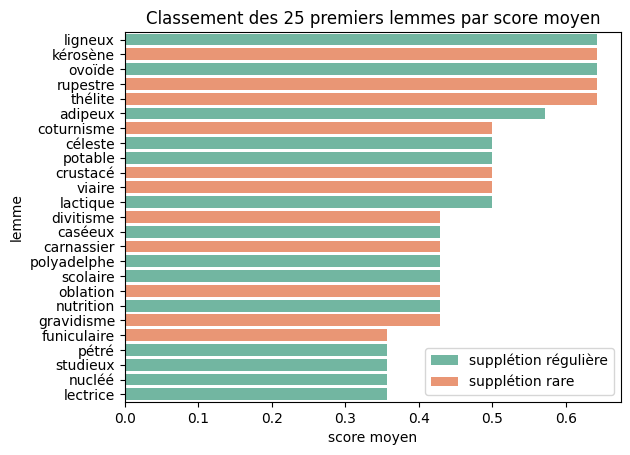

In [ ]:
# Construction d'un seul dataframe contenant les réponses de chaque question pour toutes les entrées (non dérivés et supplétifs) des trois fichiers : Gold, Non Shuffled, Shuffled
full_df = pd.read_csv(f"./{questions[0]}_annotation.csv", usecols = ["source", "lemma", questions[0]])

for q in questions :
  if q == questions[0] :
    full_df = full_df
  else :
    df_to_merge = pd.read_csv(f"./{q}_annotation.csv", usecols = ["source", "lemma", q])
    full_df = pd.merge(full_df, df_to_merge, on=["source", "lemma"])

# Construction d'un dataframe contenant uniquement les entrées supplétives du fichier Shuffled
s_df = full_df[full_df["source"] == "S"].reset_index().drop(columns=["index"])
s_df = s_df.merge(gold_dataset[["lemma", "label"]], on="lemma", how="left")
s_sup_df = s_df[s_df["label"] != "non dérivé"].reset_index().drop(columns=["index"])

# Construction d'un dataframe qui contient les scores, par question, pour chaque entrée supplétive du fichier Shuffled
infos = {"proc": s_proc_sup, "aff": s_aff_sup, "rad": s_rad_sup, "etym_mean": s_etym_mean_sup, "lang": s_lang_sup, "base": s_base_sup, "etym_fam": s_etym_fam_sup}

s_sup_scores_df = s_sup_df

for k, v in infos.items() :
  s_sup_scores_df = s_sup_scores_df.merge(v[["source", "lemma", "score"]], on=["source", "lemma"], how="left")
  s_sup_scores_df[k] = s_sup_scores_df["score"]
  s_sup_scores_df = s_sup_scores_df.drop(columns="score")

# Construction d'un dataframe qui contient le score moyen pour chaque entrée supplétive du fichier Shuffled
cols = ["proc", "aff", "rad", "etym_mean", "lang", "base", "etym_fam"]

s_sup_scores_df["mean_score"] = s_sup_scores_df[cols].mean(axis=1)

# Classement des 25 premières entrées avec le plus de réponses correctes
data = s_sup_scores_df.drop(columns=["source", "proc", "aff", "rad", "etym_mean", "lang", "base", "etym_fam"]).sort_values(by="mean_score", ascending=False)
data = data.rename(columns={"lemma" : "lemme", "mean_score" : "score moyen"})

sns.barplot(
    data=data[:25],
    x="score moyen",
    y="lemme",
    hue = "label",
    palette="Set2"
)

plt.legend(title=None)
plt.title("Classement des 25 premiers lemmes par score moyen")
plt.show()

Nous remarquons que ce ne sont pas nécessairement les supplétions rares qui sont difficiles pour le LLM.

In [ ]:
#que pour les supplétifs

print(f"mean score de proc : {mean_score_q1}")
print(f"mean score de aff : {mean_score_q2}")
print(f"mean score de rad : {mean_score_q3}")
print(f"mean score de etym_mean : {mean_score_q4}")
print(f"mean score de lang : {mean_score_q5}")
print(f"mean score de base : {mean_score_q6}")
print(f"mean score de etym_fam : {mean_score_q7}")

mean score de proc : 0.5
mean score de aff : 0.22
mean score de rad : 0.33
mean score de etym_mean : 0.24
mean score de lang : 0.86
mean score de base : 0.27
mean score de etym_fam : 0.07
